# **Лаболаторная работа №1**

---

## Загрузка и первичный осмотр таблицы

In [126]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from feature_engine.encoding import OneHotEncoder
from sklearn.model_selection import train_test_split, learning_curve
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, roc_curve

In [127]:
warnings.filterwarnings('ignore', category=pd.errors.DtypeWarning)
df = pd.read_csv('student_lifestyle_100k.csv')

Посмотрим на размерность данных и типы переменных

In [128]:
print("\nРазмер датасета:")
print(df.shape)

print("\nТипы данных и пропуски:")
print(df.info())

print("\nПервые 5 строк:")
display(df.head())


Размер датасета:
(100000, 11)

Типы данных и пропуски:
<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 11 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   Student_ID          100000 non-null  int64  
 1   Age                 100000 non-null  int64  
 2   Gender              100000 non-null  str    
 3   Department          100000 non-null  str    
 4   CGPA                100000 non-null  float64
 5   Sleep_Duration      100000 non-null  float64
 6   Study_Hours         100000 non-null  float64
 7   Social_Media_Hours  100000 non-null  float64
 8   Physical_Activity   100000 non-null  object 
 9   Stress_Level        100000 non-null  int64  
 10  Depression          100000 non-null  bool   
dtypes: bool(1), float64(4), int64(3), object(1), str(2)
memory usage: 7.7+ MB
None

Первые 5 строк:


,Student_ID,Age,Gender,Department,CGPA,Sleep_Duration,Study_Hours,Social_Media_Hours,Physical_Activity,Stress_Level,Depression
0,1001,22,Female,Science,3.50,7.3,3.3,3.4,114,5,False
1,1002,20,Male,Engineering,2.72,5.5,7.2,6.0,142,2,False
2,1003,20,Male,Medical,3.01,5.4,2.3,1.8,137,3,False
3,1004,21,Male,Engineering,3.63,8.1,2.0,4.6,130,3,False
4,1005,19,Male,Arts,3.14,6.8,2.6,4.3,4,6,False


Датасет состоит из 100 000 строк и 11 столбцов. Мы имеем как количественные признаки (Age, CGPA, Study_Hours), так и категориальные (Gender, Department)

## Переходим к предобработке данных. Проанализируем что мы сейчас имеем


#### Прежде чем строить графики, необходимо проверить данные. Проверим наличие явных и скрытых пропусков, а также логических аномалий.

Проверим пропуски отдельно

In [129]:
df.isnull().sum()

Student_ID            0
Age                   0
Gender                0
Department            0
CGPA                  0
Sleep_Duration        0
Study_Hours           0
Social_Media_Hours    0
Physical_Activity     0
Stress_Level          0
Depression            0
dtype: int64

Явных пропусков нет

Посмотрим дубликаты

In [130]:
print(f"Количество полных дубликатов: {df.duplicated().sum()}")

Количество полных дубликатов: 0


дубликатов 0, значит удалять ничего

Проверим на логические ошибки

In [131]:
display(df.describe())

,Student_ID,Age,CGPA,Sleep_Duration,Study_Hours,Social_Media_Hours,Stress_Level
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,51000.500000,21.009010,2.898316,6.996425,4.509517,3.503288,4.131660
std,28867.657797,2.000382,0.532240,1.498682,1.976076,1.486852,1.424151
min,1001.000000,18.000000,1.560000,3.000000,0.000000,0.000000,2.000000
25%,26000.750000,19.000000,2.450000,6.000000,3.200000,2.500000,3.000000
50%,51000.500000,21.000000,2.900000,7.000000,4.500000,3.500000,4.000000
75%,76000.250000,23.000000,3.350000,8.000000,5.800000,4.500000,5.000000
max,101000.000000,24.000000,4.000000,12.000000,12.800000,10.000000,10.000000


In [132]:
categorical_cols = df.select_dtypes(include=["object", "string"]).columns
for col in categorical_cols:
    print(f"{col}: {df[col].unique()[:10]}")

Gender: <StringArray>
['Female', 'Male']
Length: 2, dtype: str
Department: <StringArray>
['Science', 'Engineering', 'Medical', 'Arts', 'Business']
Length: 5, dtype: str
Physical_Activity: ['114' '142' '137' '130' '4' '129' ' ' '68' '82' '59']


Возраст записан реалистично (18 - 24)

Поля так же заполнены корректно (то есть не такого, что одно и тоже названо по разному(например M и Male))

В физической активности есть  '  ' , значит пропуски всё же присутствуют и их надо обработать

In [133]:
df['Physical_Activity'] = pd.to_numeric(df['Physical_Activity'], errors='coerce')

df['Physical_Activity'] = df['Physical_Activity'].fillna(0)

#### Проверим есть ли студенты с лишними часами в сутках

Сначала приведём все показатели к одной единице измерения - часы в сутки

In [136]:
# (Минуты / 60 = часы в неделю) -> (Часы в неделю / 7 = часы в сутки)
df['Physical_Activity_Daily_Hours'] = (df['Physical_Activity'] / 60) / 7

df['Total_Daily_Hours'] = (
    df['Sleep_Duration'] +
    df['Study_Hours'] +
    df['Social_Media_Hours'] +
    df['Physical_Activity_Daily_Hours']
)

super_students = df[df['Total_Daily_Hours'] > 24]

print(f"Количество студентов, у которых больше 24 часов в сутках: {len(super_students)}")

Количество студентов, у которых больше 24 часов в сутках: 109


Таких студентов оказалось аж 109, удалим их

In [137]:
df = df[df['Total_Daily_Hours'] <= 24]

## Переходим к разведочнму анализу данных и визуализации

удалим столбец с ID студентов, так как он будет только путать



In [76]:
df = df.drop(columns=['Student_ID'])

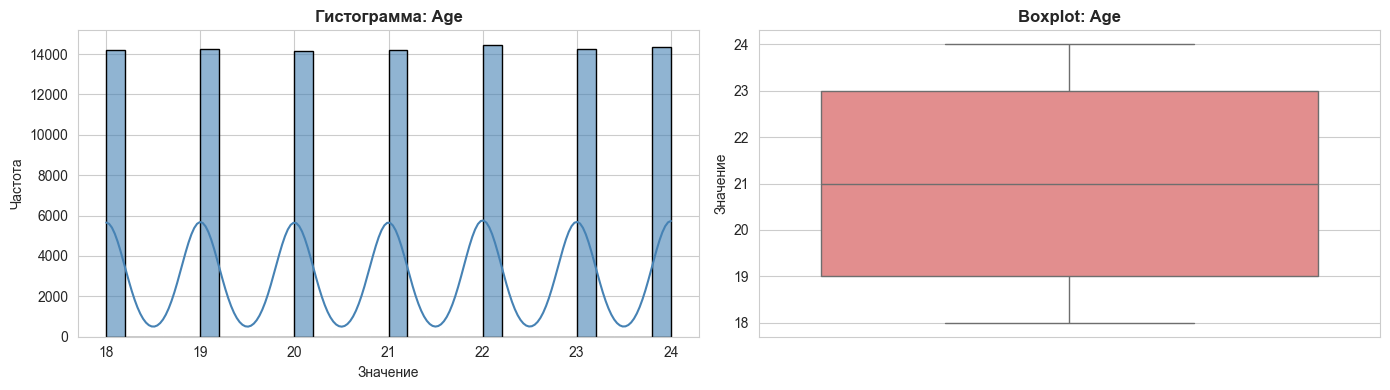

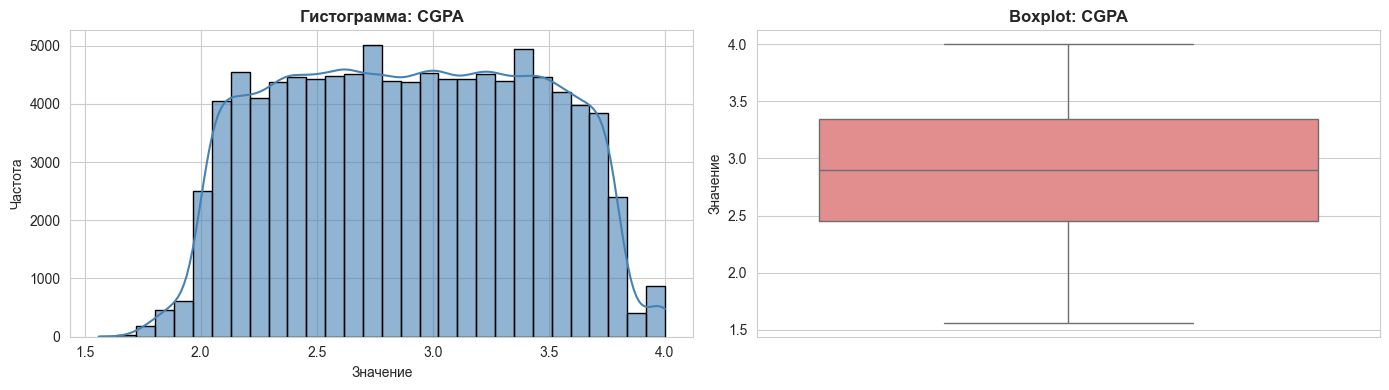

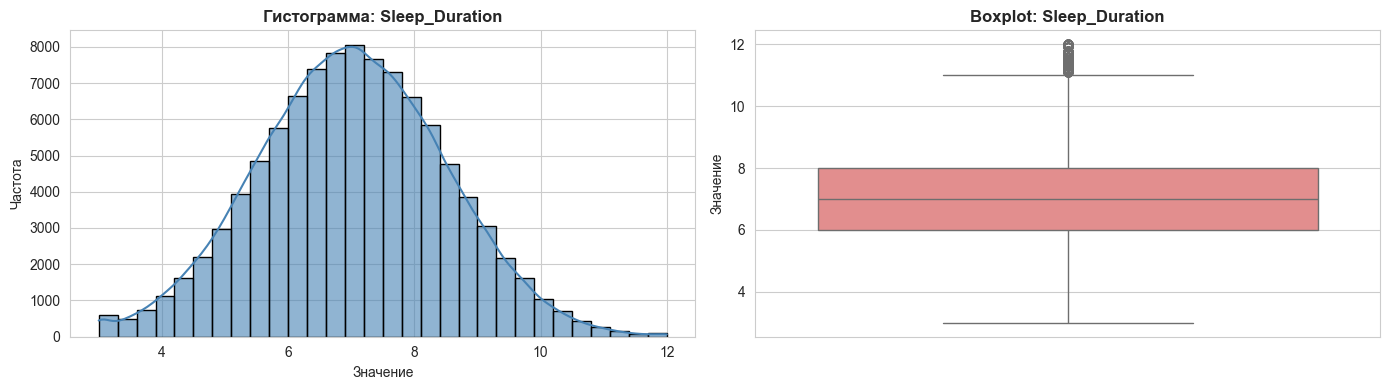

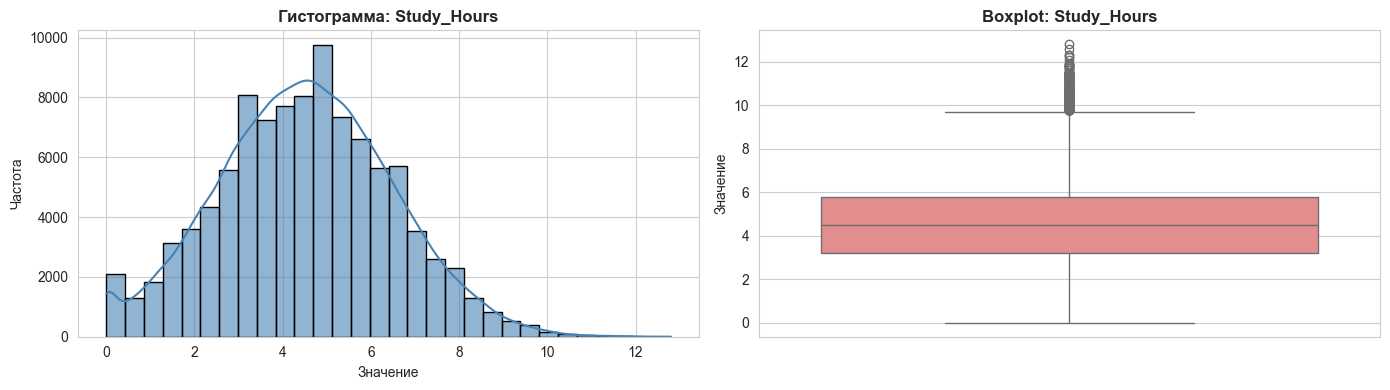

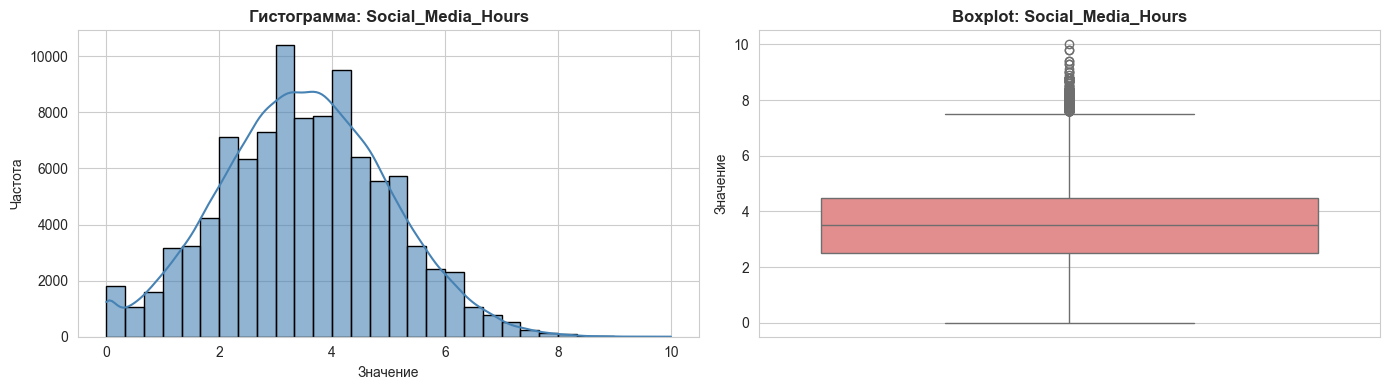

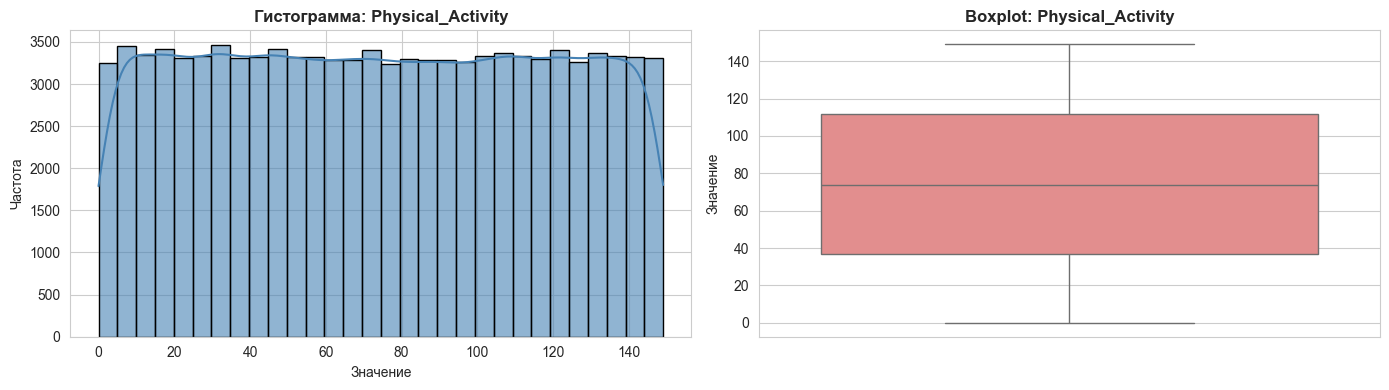

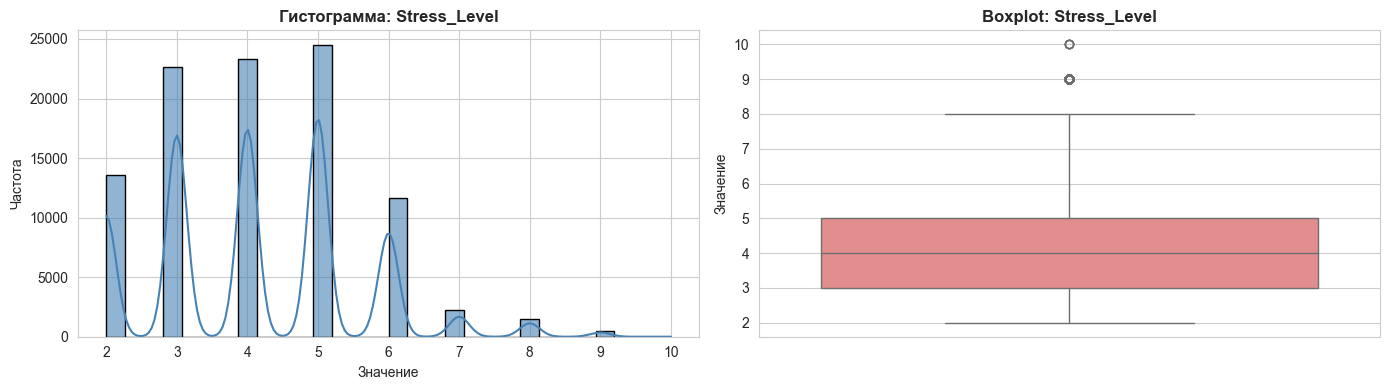

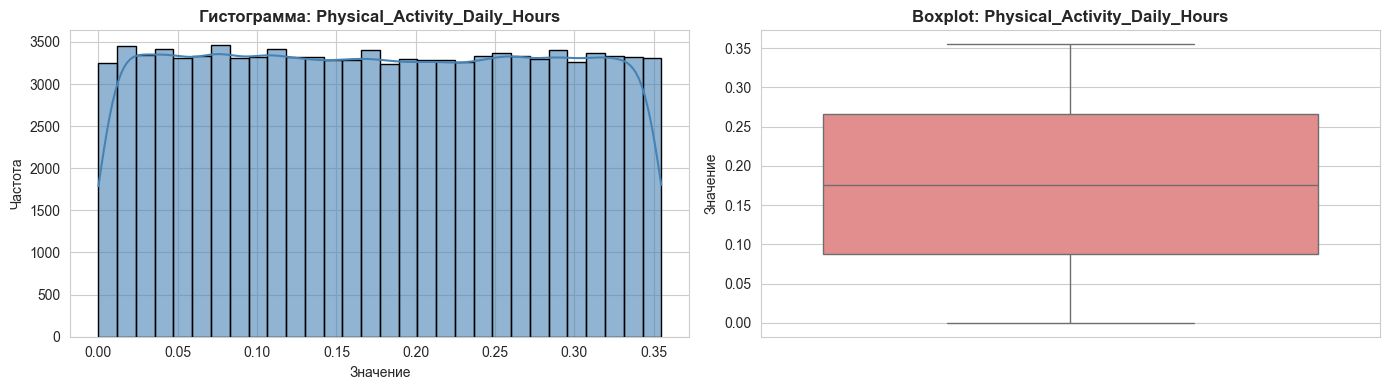

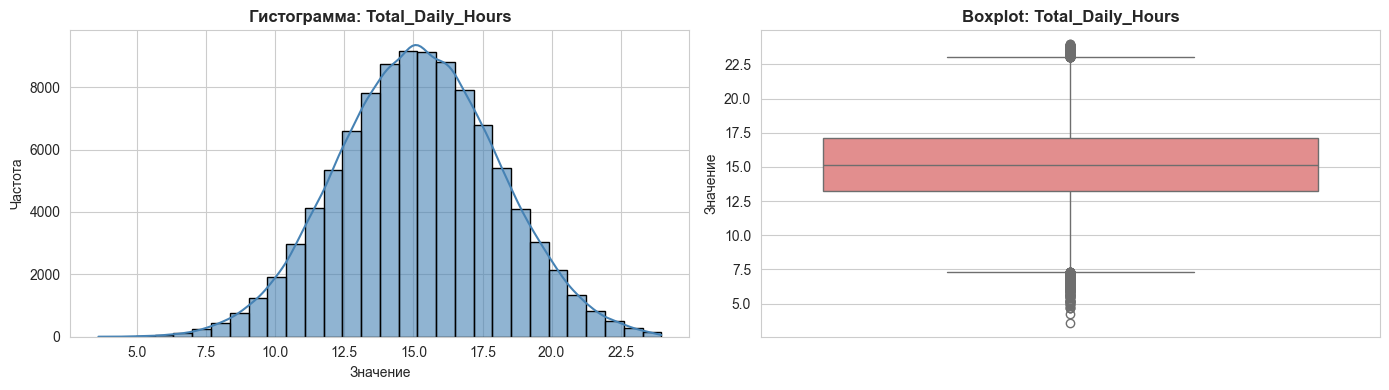

In [77]:
warnings.filterwarnings('ignore', category=UserWarning, module='matplotlib')

sns.set_style("whitegrid")
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (16, 5)


num_features = df.select_dtypes(include='number').columns.tolist()

for feat in num_features:
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    # Гистограмма + KDE
    sns.histplot(data=df, x=feat, bins=30, kde=True, ax=axes[0],
                 color='steelblue', edgecolor='black', alpha=0.6)
    axes[0].set_title(f'Гистограмма: {feat}', fontsize=12, fontweight='bold')
    axes[0].set_xlabel('Значение')
    axes[0].set_ylabel('Частота')

    # Boxplot
    sns.boxplot(data=df, y=feat, ax=axes[1], color='lightcoral')
    axes[1].set_title(f'Boxplot: {feat}', fontsize=12, fontweight='bold')
    axes[1].set_ylabel('Значение')

    plt.tight_layout()
    plt.show()

Что мы видим на графиках:
- Age: распределение равномерное в диапазоне 18-24 лет
- CGPA: наблюдается нормальное распределение
- Sleep Duration: большинство студентов спят около 7 часов
- Study Hours: распределение имеет небольшой скос влево
- Stress Level: заметно, что уровень стресса распределен дискретно
- Total_Daily_Hours: имеет скос вправо

#### Изучим отдельно выбросы

Проведем чистку с помощью квартилей

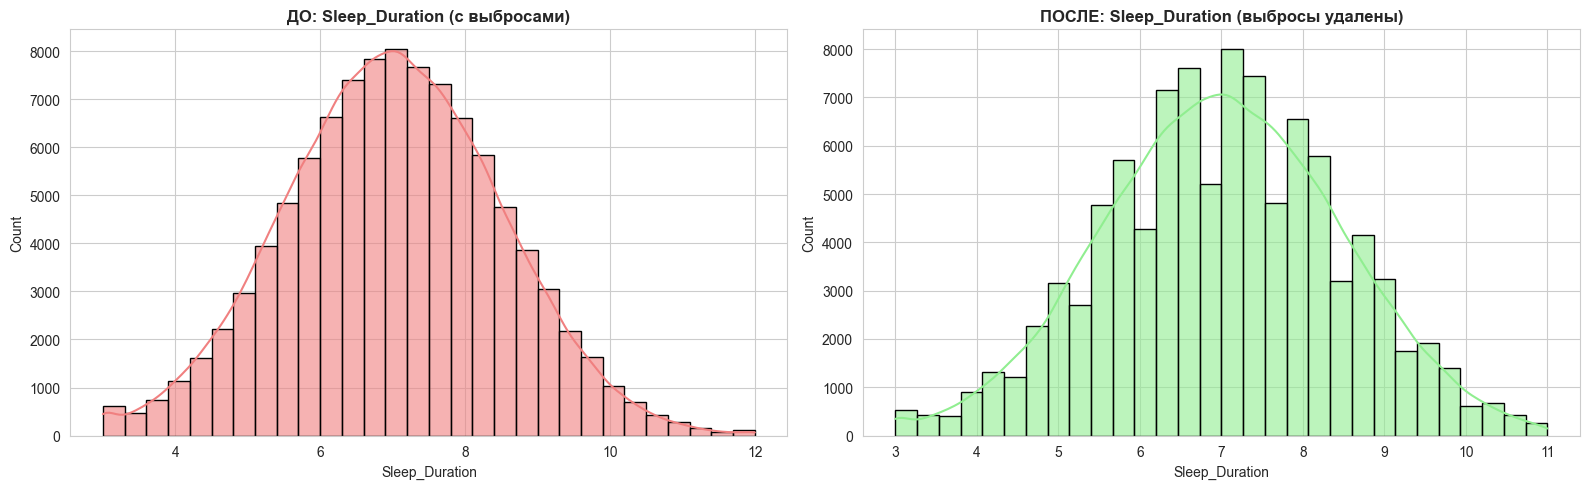

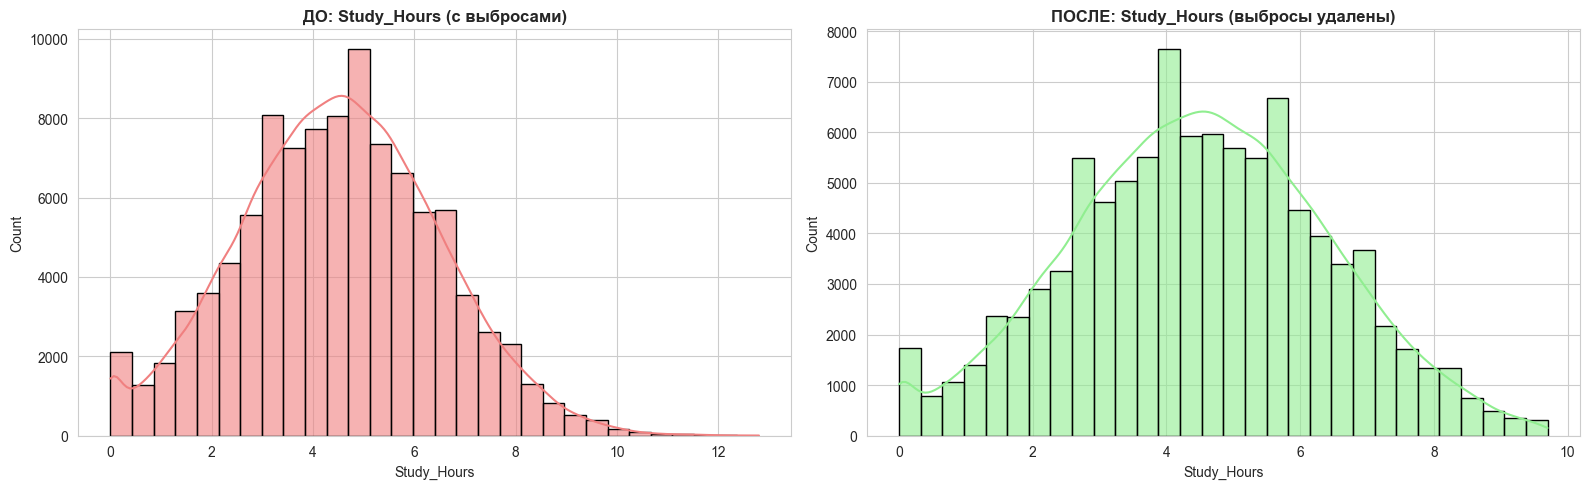

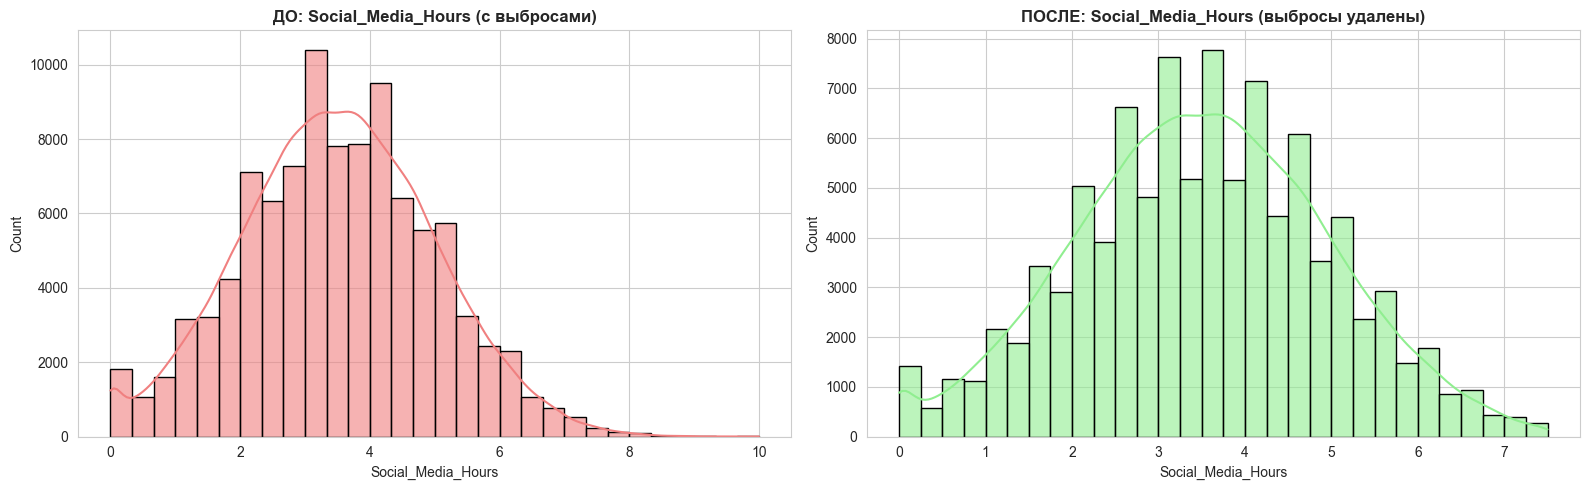

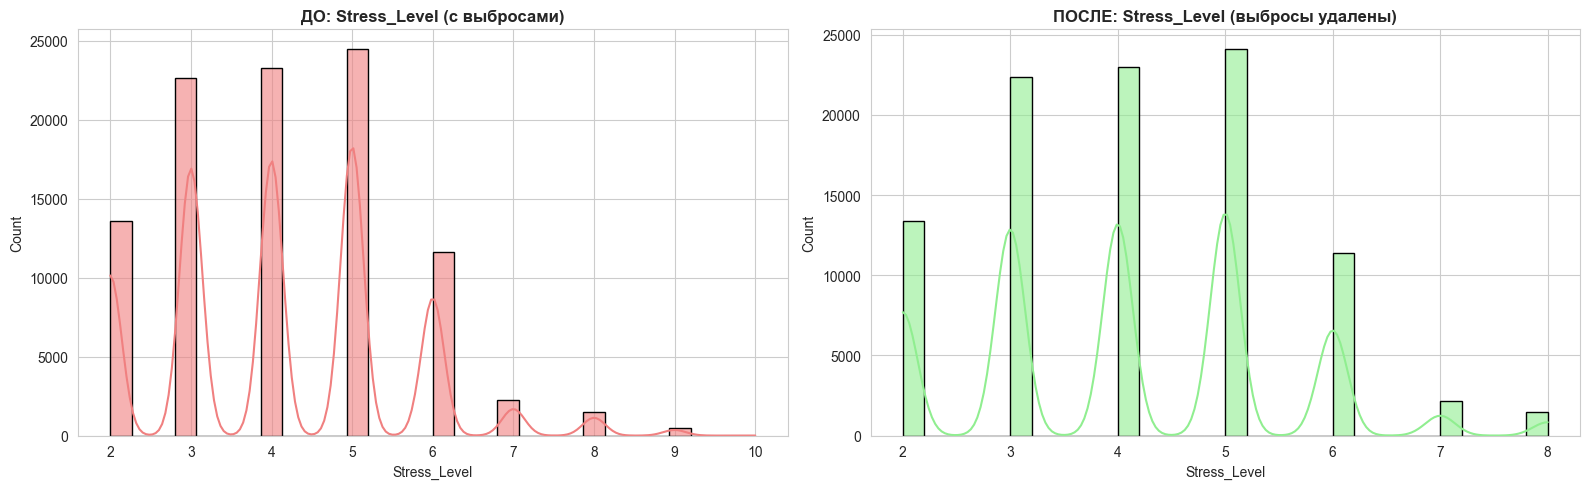

In [78]:
outliers_features = ['Sleep_Duration', 'Study_Hours', 'Social_Media_Hours', 'Stress_Level']

df_clean = df.copy()

for feat in num_features:
  Q1 = df_clean[feat].quantile(0.25)
  Q3 = df_clean[feat].quantile(0.75)
  IQR = Q3 - Q1

  lower_bound = Q1 - 1.5 * IQR
  upper_bound = Q3 + 1.5 * IQR

  df_clean = df_clean[(df_clean[feat] >= lower_bound) & (df_clean[feat] <= upper_bound)]

for feat in outliers_features:
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    # График ДО
    sns.histplot(data=df, x=feat, bins=30, kde=True, ax=axes[0], color='lightcoral', edgecolor='black', alpha=0.6)
    axes[0].set_title(f'ДО: {feat} (с выбросами)', fontsize=12, fontweight='bold')

    # График ПОСЛЕ
    sns.histplot(data=df_clean, x=feat, bins=30, kde=True, ax=axes[1], color='lightgreen', edgecolor='black', alpha=0.6)
    axes[1].set_title(f'ПОСЛЕ: {feat} (выбросы удалены)', fontsize=12, fontweight='bold')

    plt.tight_layout()
    plt.show()

 После удаления выбросов кривые плотности (KDE) на зеленых графиках стали более симметричными и «колоколообразными».
 Sleep Duration: исчезли значения менее 3 и более 11–12 часов
 Study Hours: исчезли студенты, которые учатся по 12+ часов в день
 Social Media Hours: ушли значения выше 7-8 часов
 Stress Level: ушли крайние значения

#### проведем анализ категориальных признаков

Числовые данные мы изучили, теперь посмотрим на распределение студентов по полу, факультетам и наличию депрессии. Это поможет понять, насколько сбалансирована наша выборка

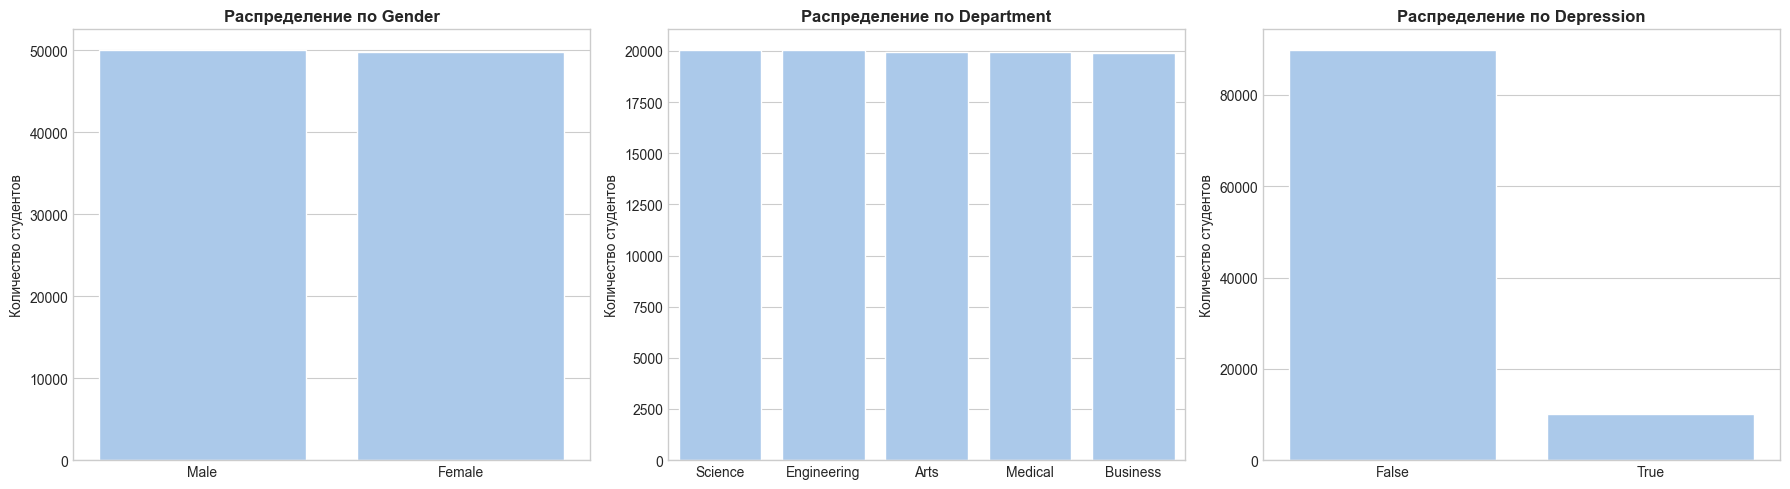

In [138]:
sns.set_palette("pastel")
plt.rcParams['figure.figsize'] = (18, 5)

# Список категориальных колонок (Gender, Department, Depression)
cat_features = ['Gender', 'Department', 'Depression']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, col in enumerate(cat_features):
    sns.countplot(data=df, x=col, ax=axes[i], order=df[col].value_counts().index)
    axes[i].set_title(f'Распределение по {col}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Количество студентов')

plt.tight_layout()
plt.show()

мы видим, что практически все признаки сбалансированны, однако студентов с депрессией сильно меньше

#### Сбалансируем количество студентов с депрессией и без неё

In [80]:
# Разделяем на два класса
df_depressed = df[df['Depression'] == True]
df_healthy = df[df['Depression'] == False]

# Берем случайную подборку здоровых студентов, равную количеству депрессивных
df_healthy_downsampled = df_healthy.sample(n=len(df_depressed), random_state=42)

# Соединяем обратно
df_balanced = pd.concat([df_depressed, df_healthy_downsampled])

df_balanced = df_balanced.sample(frac=1, random_state=42).reset_index(drop=True)


#### Перейдем к кодированию категориальных признаков

Используем Label Encoding для бинарных признаков (Gender и Depression) и One-Hot Encoding для Department

In [81]:
# Создаем копию для кодирования
df_encoded = df_balanced.copy()

df_encoded['Gender'] = df_encoded['Gender'].astype('category').cat.codes
df_encoded['Depression'] = df_encoded['Depression'].astype(int)

ohe = OneHotEncoder(variables=['Department'], drop_last=True)
df_encoded = ohe.fit_transform(df_encoded)

Построим матрицу корреляций

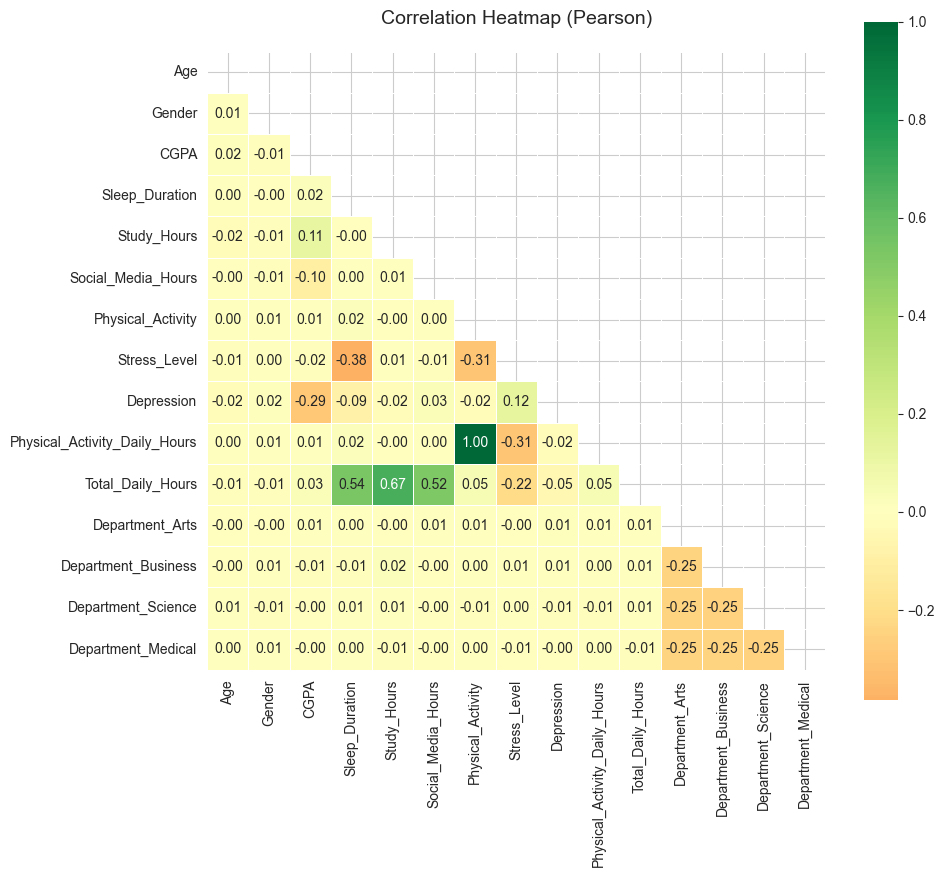

In [83]:
def plot_correlation_heatmap(dataframe, method='pearson'):
    numeric_df = dataframe.select_dtypes(include=[np.number])
    corr = numeric_df.corr(method=method)

    plt.figure(figsize=(10, 10))

    mask = np.triu(np.ones_like(corr, dtype=bool))
    sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn', center=0, square=True, linewidths=0.5, cbar_kws={"shrink": .8})

    plt.title(f'Correlation Heatmap ({method.capitalize()})', fontsize=14, pad=20)
    plt.tight_layout()
    plt.show()

plot_correlation_heatmap(df_encoded)

По матрице мы видим, что самая сильная связь у депрессии наблюдается с CGPA (-0.29). Отрицательная корреляция говорит о том, что у студентов с более высоким средним баллом риск депрессии в этом датасете ниже. Также есть связь между уровнем стресса и сном(-0.38), и физической активностью(-0.31). Также Стали видны лишние колонки, Physical_Activity и Total_Daily_Hours. Их надо удалить

In [84]:
cols_to_drop = ['Physical_Activity', 'Total_Daily_Hours']
df_final = df_encoded.drop(columns=cols_to_drop)

Ещё раз посмотрим на матрицу корреляций

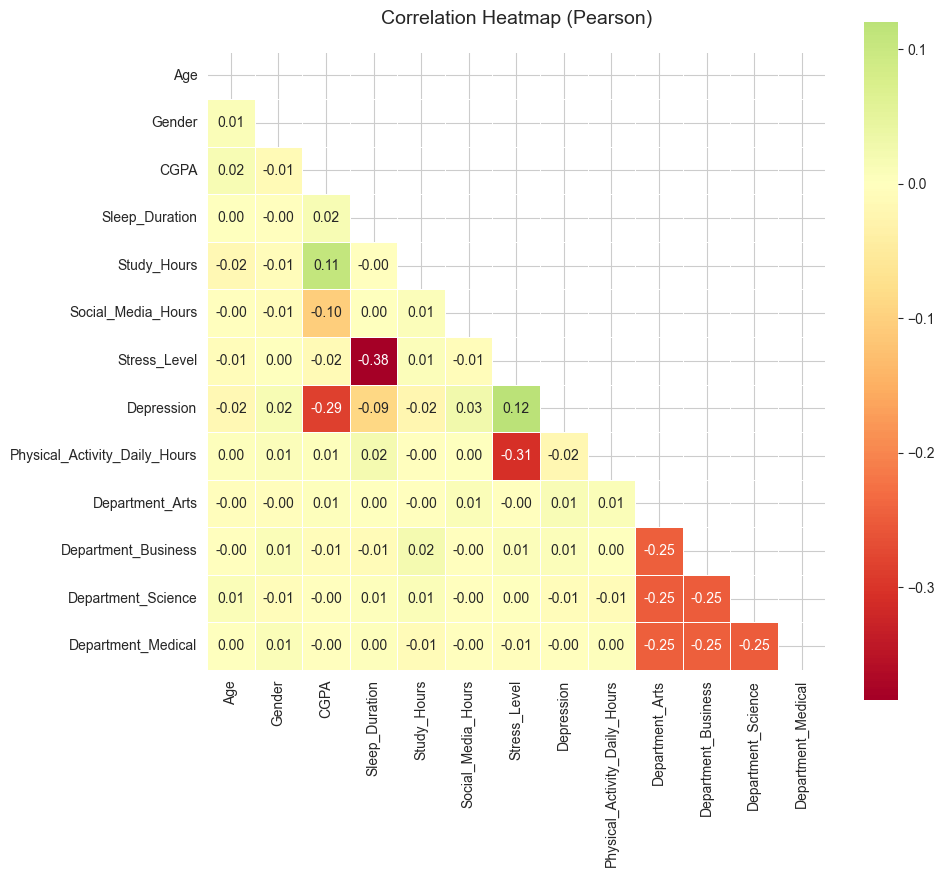

In [85]:
plot_correlation_heatmap(df_final)

Здесь уже почти нет созависимых признаков, можем переходить к следующему шагу

#### Разделим данные на обучающую, валидационную и тестовую выборки

In [139]:
# Определяем признаки (X) и целевые переменные (y)
# Убираем оба таргета из признаков
X = df_final.drop(columns=['CGPA', 'Depression'], errors='ignore')
y_reg = df_final['CGPA']
y_cls = df_final['Depression']

# Сначала отделяем 60% на обучение и 40% на временный набор
X_train, X_temp, y_train_reg, y_temp_reg, y_train_cls, y_temp_cls = train_test_split(X, y_reg, y_cls, test_size=0.4, random_state=42)

# 3. Делим временный набор пополам (20% Val и 20% Test от общего объема)
X_val, X_test, y_val_reg, y_test_reg, y_val_cls, y_test_cls = train_test_split( X_temp, y_temp_reg, y_temp_cls, test_size=0.5, random_state=42)

print(f"Размер обучающей выборки: {X_train.shape[0]}")
print(f"Размер валидационной выборки: {X_val.shape[0]}")
print(f"Размер тестовой выборки: {X_test.shape[0]}")

Размер обучающей выборки: 12061
Размер валидационной выборки: 4020
Размер тестовой выборки: 4021


#### Feature Engineering

In [140]:
scaler = StandardScaler()

# Обучаем scaler только на тренировочных данных
X_train_scaled = scaler.fit_transform(X_train)

# Применяем (трансформируем) к валидации и тесту
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# Превратим обратно в DataFrame для удобства
X_train_final = pd.DataFrame(X_train_scaled, columns=X.columns)
X_val_final = pd.DataFrame(X_val_scaled, columns=X.columns)
X_test_final = pd.DataFrame(X_test_scaled, columns=X.columns)

X_train_final.head()

,Age,Gender,Sleep_Duration,Study_Hours,Social_Media_Hours,Stress_Level,Physical_Activity_Daily_Hours,Department_Arts,Department_Business,Department_Science,Department_Medical
0,-0.000373,-0.986903,0.534320,1.374241,0.853750,0.475412,1.738490,-0.497511,-0.495436,-0.505151,-0.494657
1,-0.000373,1.013271,0.149922,-0.067196,-0.692984,-0.162331,-1.136050,-0.497511,-0.495436,-0.505151,-0.494657
2,1.500171,-0.986903,0.085856,-0.170156,-1.634475,0.475412,1.071597,-0.497511,2.018426,-0.505151,-0.494657
3,0.999990,1.013271,0.149922,0.756483,-0.894732,-1.437817,0.266726,-0.497511,2.018426,-0.505151,-0.494657
4,-0.500555,-0.986903,0.918718,0.962402,-0.827483,-1.437817,0.565678,2.010004,-0.495436,-0.505151,-0.494657


Не пугаемся отрицательным значениям. Они появились из-за использования StandardScaler. Этот метод сдвигает и масштабирует данные так, чтобы среднее значение (Mean) каждого признака стало равно 0, а стандартное отклонение стало равно 1. Это нам нужно будет для линейной модели

#### Переходим к Линейной регрессии

Предскажем успеваемость студентов, а так же выведем метрики модели


Метрики для Train:
  MAE:  0.4761
  RMSE: 0.5448
  R²:   0.0243
  MAPE: 17.75%

Метрики для Validation:
  MAE:  0.4735
  RMSE: 0.5426
  R²:   0.0214
  MAPE: 17.48%

Метрики для Test:
  MAE:  0.4750
  RMSE: 0.5443
  R²:   0.0224
  MAPE: 17.68%


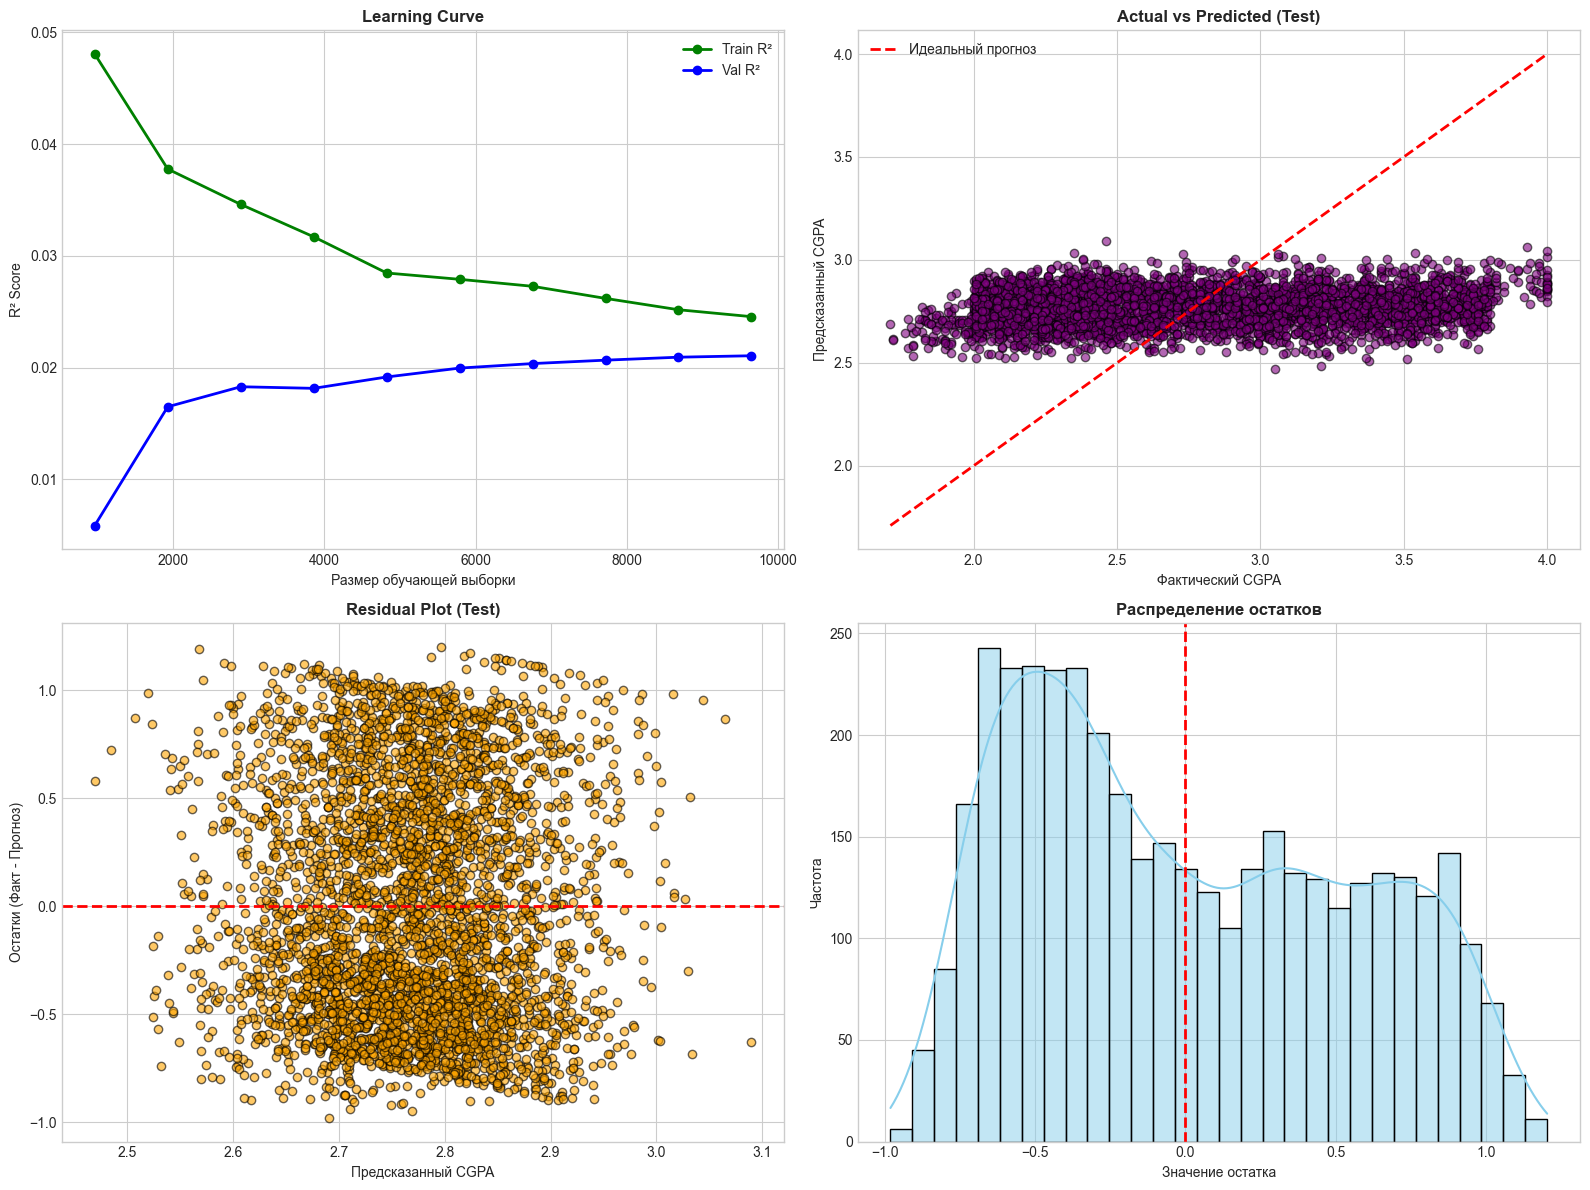


Влияние признаков на CGPA:
Study_Hours                      0.058574
Department_Arts                  0.011291
Department_Medical               0.007359
Age                              0.006710
Sleep_Duration                   0.003657
Department_Science               0.001395
Physical_Activity_Daily_Hours    0.001316
Department_Business             -0.004005
Stress_Level                    -0.006687
Gender                          -0.006702
Social_Media_Hours              -0.061144
dtype: float64


In [141]:
# 1. Создаем и обучаем модель
model_reg = LinearRegression()
model_reg.fit(X_train_final, y_train_reg)

# 2. Получаем прогнозы
y_train_pred = model_reg.predict(X_train_final)
y_val_pred = model_reg.predict(X_val_final)
y_test_pred = model_reg.predict(X_test_final)

# 3. Оцениваем качество модели
def evaluate_model(y_true, y_pred, dataset_name="Dataset"):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    mape = mean_absolute_percentage_error(y_true, y_pred) * 100

    print(f"\nМетрики для {dataset_name}:")
    print(f"  MAE:  {mae:.4f}")
    print(f"  RMSE: {rmse:.4f}")
    print(f"  R²:   {r2:.4f}")
    print(f"  MAPE: {mape:.2f}%")

    return {'MAE': mae, 'RMSE': rmse, 'R2': r2, 'MAPE': mape}

# 4. Оцениваем на всех трех выборках
train_metrics = evaluate_model(y_train_reg, y_train_pred, "Train")
val_metrics = evaluate_model(y_val_reg, y_val_pred, "Validation")
test_metrics = evaluate_model(y_test_reg, y_test_pred, "Test")

# 5. Выводим результаты
plt.style.use('seaborn-v0_8-whitegrid')
fig = plt.figure(figsize=(16, 12))

# 6. Кривая обучения
ax1 = plt.subplot(2, 2, 1)
train_sizes, train_scores, val_scores = learning_curve(
    model_reg, X_train_final, y_train_reg,
    cv=5,
    train_sizes=np.linspace(0.1, 1.0, 10),
    scoring='r2',
    n_jobs=-1
)

train_mean = np.mean(train_scores, axis=1)
val_mean = np.mean(val_scores, axis=1)

ax1.plot(train_sizes, train_mean, 'o-', color='green', label='Train R²', linewidth=2)
ax1.plot(train_sizes, val_mean, 'o-', color='blue', label='Val R²', linewidth=2)
ax1.set_xlabel('Размер обучающей выборки')
ax1.set_ylabel('R² Score')
ax1.set_title('Learning Curve', fontsize=12, fontweight='bold')
ax1.legend()

# 7. Фактическое и прогнозируемое
ax2 = plt.subplot(2, 2, 2)
ax2.scatter(y_test_reg, y_test_pred, alpha=0.6, edgecolors='black', color='purple')
ax2.plot([y_test_reg.min(), y_test_reg.max()], [y_test_reg.min(), y_test_reg.max()], 'r--', lw=2, label='Идеальный прогноз')
ax2.set_xlabel('Фактический CGPA')
ax2.set_ylabel('Предсказанный CGPA')
ax2.set_title('Actual vs Predicted (Test)', fontsize=12, fontweight='bold')
ax2.legend()

# 8. Остатки
ax3 = plt.subplot(2, 2, 3)
residuals = y_test_reg - y_test_pred
ax3.scatter(y_test_pred, residuals, alpha=0.6, edgecolors='black', color='orange')
ax3.axhline(y=0, color='red', linestyle='--', lw=2)
ax3.set_xlabel('Предсказанный CGPA')
ax3.set_ylabel('Остатки (Факт - Прогноз)')
ax3.set_title('Residual Plot (Test)', fontsize=12, fontweight='bold')

# 9. Распределение остатков

ax4 = plt.subplot(2, 2, 4)
sns.histplot(residuals, bins=30, kde=True, ax=ax4, color='skyblue', edgecolor='black')
ax4.axvline(x=0, color='red', linestyle='--', lw=2)
ax4.set_xlabel('Значение остатка')
ax4.set_ylabel('Частота')
ax4.set_title('Распределение остатков', fontsize=12, fontweight='bold')


plt.tight_layout()
plt.show()
# Посмотрим на коэффициенты
weights = pd.Series(lr_model.coef_, index=X.columns).sort_values(ascending=False)
print("\nВлияние признаков на CGPA:")
print(weights)

Как мы видим, модель предсказывает очень плохо. Однако, на графике кривой обучения линии тренировочного (зеленая) и валидационного (синяя) сошлись. Значит переобучения нет).
Модель одинаково плохо работает как на данных на которых училась так и на других
Влияние признаков слишком маленькое

#### Переходим к задаче классификации

Напишем свою логическую регрессию

In [142]:
class LogisticRegressionCustom:
    def __init__(self, learning_rate=0.01, n_iterations=100, random_state=42, penalty='l2', alpha=0.01):
        self.learning_rate = learning_rate
        self.n_iterations = n_iterations
        self.random_state = random_state
        self.penalty = penalty
        self.alpha = alpha
        self.weights = None
        self.bias = None
        self.loss_history = []

    def _initialize_parameters(self, n_features):
        """Инициализация весов и смещения"""
        np.random.seed(self.random_state)
        self.weights = np.random.randn(n_features) * 0.01
        self.bias = 0.0

    def _sigmoid(self, z):
        """Сигмоидная функция активации"""
        z = np.clip(z, -500, 500)
        return 1 / (1 + np.exp(-z))

    def _compute_loss(self, y_true, y_pred_proba):
        """Вычисление Binary Cross-Entropy Loss"""
        epsilon = 1e-15
        y_pred_proba = np.clip(y_pred_proba, epsilon, 1 - epsilon)
        loss = -np.mean(y_true * np.log(y_pred_proba) + (1 - y_true) * np.log(1 - y_pred_proba))

        if self.penalty == 'l2':
            loss += (self.alpha / (2 * len(y_true))) * np.sum(self.weights ** 2)
        return loss

    def fit(self, X, y):
        """Обучение модели градиентным спуском"""
        n_samples, n_features = X.shape
        self._initialize_parameters(n_features)
        self.loss_history = []

        for epoch in range(self.n_iterations):
            linear_output = np.dot(X, self.weights) + self.bias
            y_pred_proba = self._sigmoid(linear_output)

            loss = self._compute_loss(y, y_pred_proba)
            self.loss_history.append(loss)

            error = y_pred_proba - y
            dw = (1 / n_samples) * np.dot(X.T, error)
            db = (1 / n_samples) * np.sum(error)

            if self.penalty == 'l2':
                dw += (self.alpha / n_samples) * self.weights

            self.weights -= self.learning_rate * dw
            self.bias -= self.learning_rate * db
        return self

    def predict_proba(self, X):
        """Вероятность принадлежности к классу 1"""
        linear_output = np.dot(X, self.weights) + self.bias
        return self._sigmoid(linear_output)

    def predict(self, X, threshold=0.5):
        """Предсказание класса (0 или 1)"""
        proba = self.predict_proba(X)
        return (proba >= threshold).astype(int)

#### Настроим параметры и перейдем к обучению

In [143]:
# Параметры для эксперимента (можно менять)
n_epochs = 500         # Число эпох
learning_rate = 0.1    # Шаг обучения

model_cls = LogisticRegressionCustom(
    learning_rate=learning_rate,
    n_iterations=n_epochs,
    random_state=42,
    penalty='l2',
    alpha=0.1
)

# Обучаем на подготовленных данных для классификации
model_cls.fit(X_train_final, y_train_cls)

# Прогнозы
y_train_pred = model_cls.predict(X_train_final)
y_val_pred = model_cls.predict(X_val_final)
y_test_pred = model_cls.predict(X_test_final)

y_test_proba = model_cls.predict_proba(X_test_final)

#### Оценим качество модели, выведем метрики

In [144]:
def evaluate_classification(y_true, y_pred, y_proba=None, dataset_name="Набор данных"):
    """Расчет и вывод метрик классификации"""
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    auc_roc = roc_auc_score(y_true, y_proba) if y_proba is not None else None

    print(f"\nМетрики для {dataset_name}:")
    print(f"  Accuracy:  {accuracy:.4f}")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall:    {recall:.4f}")
    print(f"  F1-Score:  {f1:.4f}")
    if auc_roc:
        print(f"  AUC-ROC:   {auc_roc:.4f}")

    return {'Accuracy': accuracy, 'Precision': precision, 'Recall': recall, 'F1': f1, 'AUC-ROC': auc_roc}

train_metrics = evaluate_classification(y_train_cls, y_train_pred, dataset_name="Train")
val_metrics = evaluate_classification(y_val_cls, y_val_pred, dataset_name="Validation")
test_metrics = evaluate_classification(y_test_cls, y_test_pred, y_proba=y_test_proba, dataset_name="Test")


Метрики для Train:
  Accuracy:  0.5421
  Precision: 0.5428
  Recall:    0.4596
  F1-Score:  0.4978

Метрики для Validation:
  Accuracy:  0.5306
  Precision: 0.5436
  Recall:    0.4536
  F1-Score:  0.4945

Метрики для Test:
  Accuracy:  0.5359
  Precision: 0.5594
  Recall:    0.4454
  F1-Score:  0.4959
  AUC-ROC:   0.5637


#### Визуализация

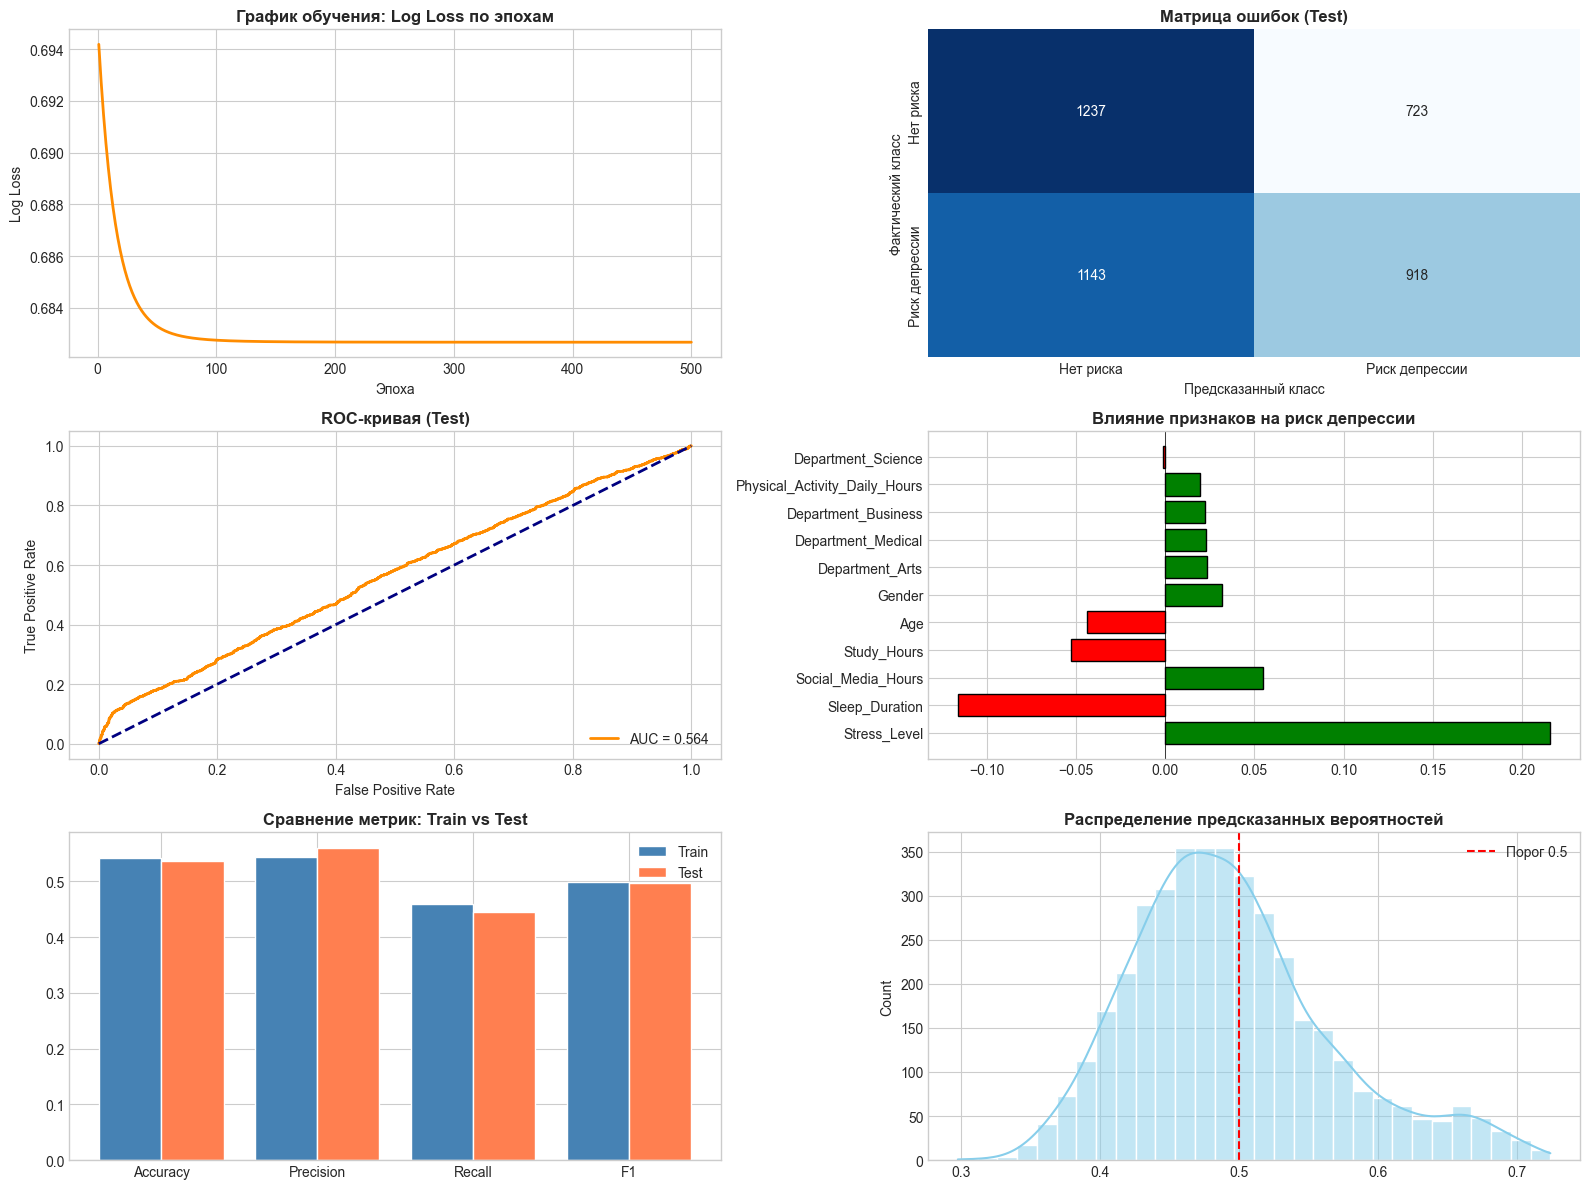

In [148]:
plt.style.use('seaborn-v0_8-whitegrid')
fig = plt.figure(figsize=(16, 12))

# 4.1 История потерь
ax1 = plt.subplot(3, 2, 1)
ax1.plot(range(1, n_epochs + 1), model_cls.loss_history, color='darkorange', linewidth=2)
ax1.set_xlabel('Эпоха')
ax1.set_ylabel('Log Loss')
ax1.set_title('График обучения: Log Loss по эпохам', fontweight='bold')

# 4.2 Матрица ошибок (Test)
ax2 = plt.subplot(3, 2, 2)
cm = confusion_matrix(y_test_cls, y_test_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax2, cbar=False)
ax2.set_xlabel('Предсказанный класс')
ax2.set_ylabel('Фактический класс')
ax2.set_title('Матрица ошибок (Test)', fontweight='bold')
ax2.set_xticklabels(['Нет риска', 'Риск депрессии'])
ax2.set_yticklabels(['Нет риска', 'Риск депрессии'])

# 4.3 ROC-кривая
ax3 = plt.subplot(3, 2, 3)
fpr, tpr, _ = roc_curve(y_test_cls, y_test_proba)
ax3.plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC = {test_metrics["AUC-ROC"]:.3f}')
ax3.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
ax3.set_xlabel('False Positive Rate')
ax3.set_ylabel('True Positive Rate')
ax3.set_title('ROC-кривая (Test)', fontweight='bold')
ax3.legend(loc="lower right")

# 4.4 Важность признаков
ax4 = plt.subplot(3, 2, 4)
weights_df = pd.DataFrame({
    'feature': X_train_final.columns,
    'weight': model_cls.weights
}).sort_values(by='weight', key=lambda x: np.abs(x), ascending=False)

colors = ['green' if w > 0 else 'red' for w in weights_df['weight']]
ax4.barh(weights_df['feature'], weights_df['weight'], color=colors, edgecolor='black')
ax4.set_title('Влияние признаков на риск депрессии', fontweight='bold')
ax4.axvline(x=0, color='black', lw=0.5)

# 4.5 Сравнение метрик
ax5 = plt.subplot(3, 2, 5)
m_names = ['Accuracy', 'Precision', 'Recall', 'F1']
train_v = [train_metrics['Accuracy'], train_metrics['Precision'], train_metrics['Recall'], train_metrics['F1']]
test_v = [test_metrics['Accuracy'], test_metrics['Precision'], test_metrics['Recall'], test_metrics['F1']]

x = np.arange(len(m_names))
ax5.bar(x - 0.2, train_v, 0.4, label='Train', color='steelblue')
ax5.bar(x + 0.2, test_v, 0.4, label='Test', color='coral')
ax5.set_xticks(x)
ax5.set_xticklabels(m_names)
ax5.set_title('Сравнение метрик: Train vs Test', fontweight='bold')
ax5.legend()

# 4.6 Распределение вероятностей
ax6 = plt.subplot(3, 2, 6)
sns.histplot(y_test_proba, bins=30, kde=True, ax=ax6, color='skyblue')
ax6.axvline(x=0.5, color='red', linestyle='--', label='Порог 0.5')
ax6.set_title('Распределение предсказанных вероятностей', fontweight='bold')
ax6.legend()

plt.tight_layout()
plt.show()

Сейчас модель предсказывает очень плохо. По первому графику видно что примерно после 150 эпох модель уже не обучается. Попробуем что-нибудь изменить. Так же расположим графики по другому для лучшей читабельности

Запуск эксперимента: LR=0.5, Эпох=1000

Метрики для Train:
  Accuracy:  0.5422
  Precision: 0.5430
  Recall:    0.4598
  F1-Score:  0.4980

Метрики для Test:
  Accuracy:  0.5354
  Precision: 0.5587
  Recall:    0.4454
  F1-Score:  0.4957
  AUC-ROC:   0.5637


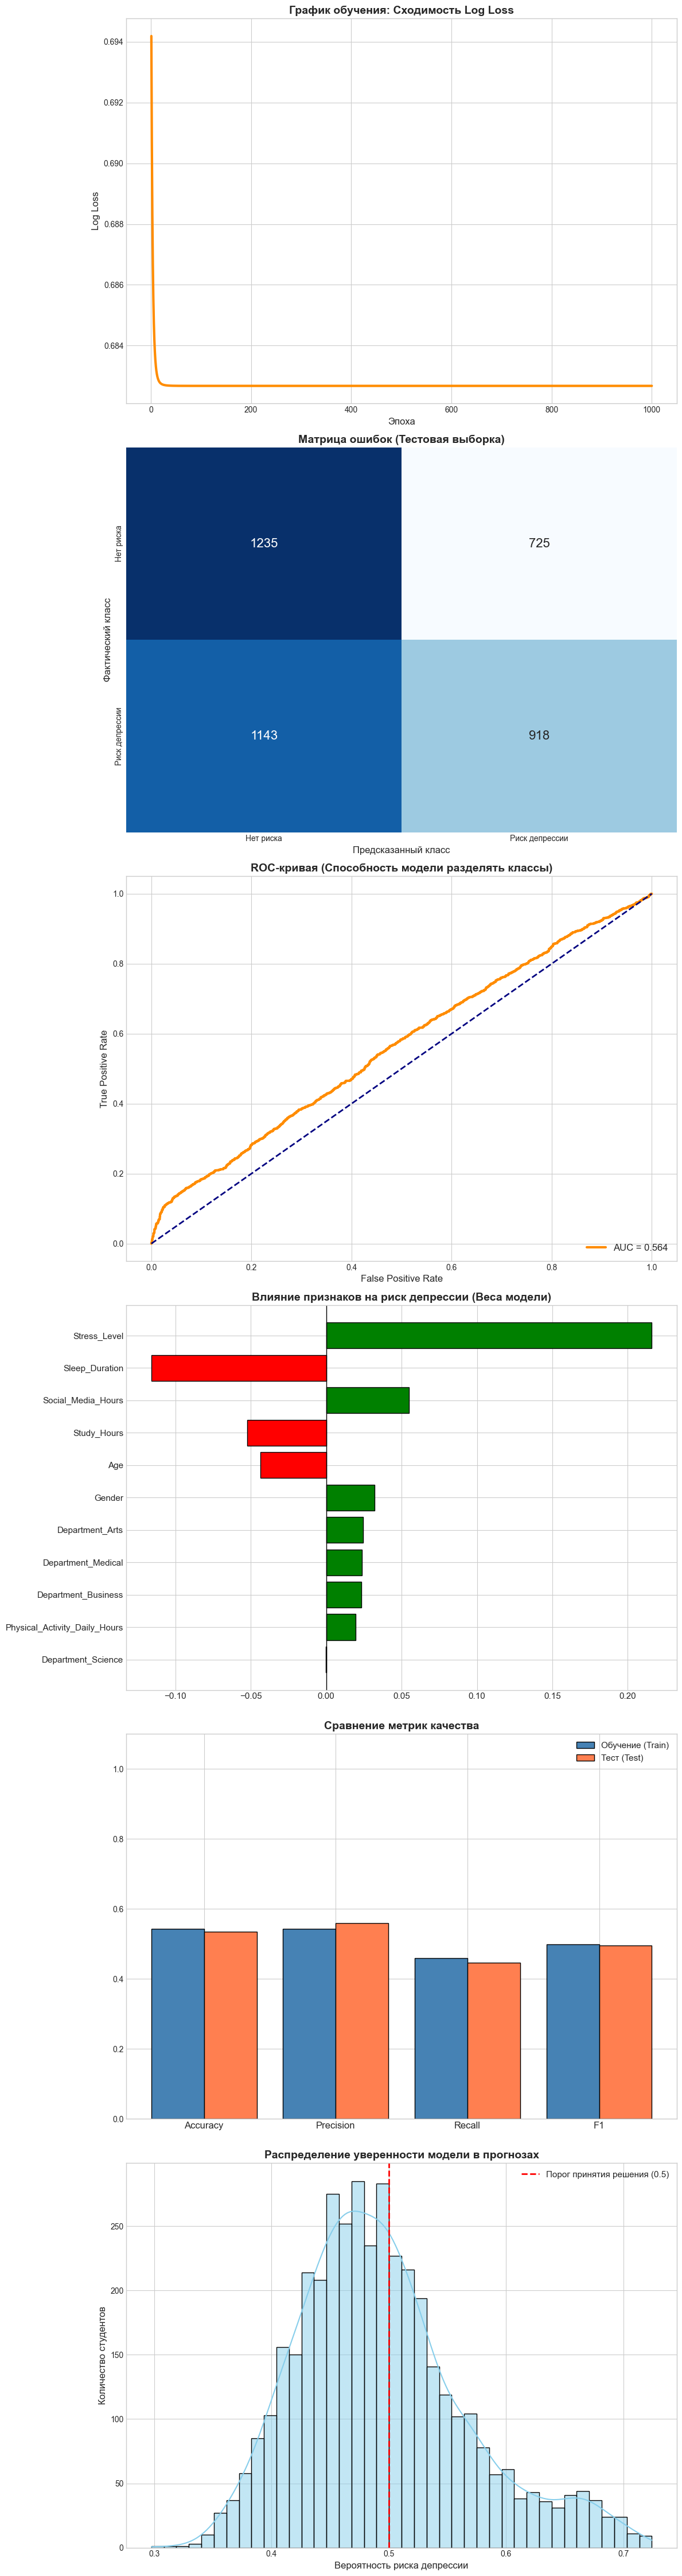

In [149]:
n_epochs = 1000
learning_rate = 0.5

print(f"Запуск эксперимента: LR={learning_rate}, Эпох={n_epochs}")

# Обучение модели
model_cls = LogisticRegressionCustom(
    learning_rate=learning_rate,
    n_iterations=n_epochs,
    random_state=42,
    penalty='l2',
    alpha=0.1
)
model_cls.fit(X_train_final, y_train_cls)

# Сбор прогнозов и метрик
y_train_pred = model_cls.predict(X_train_final)
y_test_pred = model_cls.predict(X_test_final)
y_test_proba = model_cls.predict_proba(X_test_final)

train_metrics = evaluate_classification(y_train_cls, y_train_pred, dataset_name="Train")
test_metrics = evaluate_classification(y_test_cls, y_test_pred, y_proba=y_test_proba, dataset_name="Test")

plt.style.use('seaborn-v0_8-whitegrid')

# Создаем 6 графиков в одну колонку. Высота 45 обеспечивает комфортный размер каждого.
fig, axes = plt.subplots(6, 1, figsize=(12, 45))

# 1. История потерь (Log Loss)
axes[0].plot(range(1, n_epochs + 1), model_cls.loss_history, color='darkorange', linewidth=3)
axes[0].set_xlabel('Эпоха', fontsize=12)
axes[0].set_ylabel('Log Loss', fontsize=12)
axes[0].set_title('График обучения: Сходимость Log Loss', fontsize=14, fontweight='bold')

# 2. Матрица ошибок (Test)
cm = confusion_matrix(y_test_cls, y_test_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1], cbar=False, annot_kws={"size": 16})
axes[1].set_xlabel('Предсказанный класс', fontsize=12)
axes[1].set_ylabel('Фактический класс', fontsize=12)
axes[1].set_title('Матрица ошибок (Тестовая выборка)', fontsize=14, fontweight='bold')
axes[1].set_xticklabels(['Нет риска', 'Риск депрессии'])
axes[1].set_yticklabels(['Нет риска', 'Риск депрессии'])

# 3. ROC-кривая
fpr, tpr, _ = roc_curve(y_test_cls, y_test_proba)
axes[2].plot(fpr, tpr, color='darkorange', lw=3, label=f'AUC = {test_metrics["AUC-ROC"]:.3f}')
axes[2].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axes[2].set_xlabel('False Positive Rate', fontsize=12)
axes[2].set_ylabel('True Positive Rate', fontsize=12)
axes[2].set_title('ROC-кривая (Способность модели разделять классы)', fontsize=14, fontweight='bold')
axes[2].legend(loc="lower right", fontsize=12)

# 4. Важность признаков (Коэффициенты весов)
weights_df = pd.DataFrame({
    'feature': X_train_final.columns,
    'weight': model_cls.weights
}).sort_values(by='weight', key=lambda x: np.abs(x), ascending=True)

colors = ['green' if w > 0 else 'red' for w in weights_df['weight']]
axes[3].barh(weights_df['feature'], weights_df['weight'], color=colors, edgecolor='black')
axes[3].set_title('Влияние признаков на риск депрессии (Веса модели)', fontsize=14, fontweight='bold')
axes[3].axvline(x=0, color='black', lw=1)
axes[3].tick_params(axis='both', which='major', labelsize=11)

# 5. Сравнение основных метрик (Train vs Test)
m_names = ['Accuracy', 'Precision', 'Recall', 'F1']
train_v = [train_metrics['Accuracy'], train_metrics['Precision'], train_metrics['Recall'], train_metrics['F1']]
test_v = [test_metrics['Accuracy'], test_metrics['Precision'], test_metrics['Recall'], test_metrics['F1']]

x_axis = np.arange(len(m_names))
axes[4].bar(x_axis - 0.2, train_v, 0.4, label='Обучение (Train)', color='steelblue', edgecolor='black')
axes[4].bar(x_axis + 0.2, test_v, 0.4, label='Тест (Test)', color='coral', edgecolor='black')
axes[4].set_xticks(x_axis)
axes[4].set_xticklabels(m_names, fontsize=12)
axes[4].set_ylim(0, 1.1)
axes[4].set_title('Сравнение метрик качества', fontsize=14, fontweight='bold')
axes[4].legend(fontsize=11)

# 6. Распределение предсказанных вероятностей
sns.histplot(y_test_proba, bins=40, kde=True, ax=axes[5], color='skyblue', edgecolor='black')
axes[5].axvline(x=0.5, color='red', linestyle='--', linewidth=2, label='Порог принятия решения (0.5)')
axes[5].set_xlabel('Вероятность риска депрессии', fontsize=12)
axes[5].set_ylabel('Количество студентов', fontsize=12)
axes[5].set_title('Распределение уверенности модели в прогнозах', fontsize=14, fontweight='bold')
axes[5].legend(fontsize=11)

plt.tight_layout()
plt.show()

После ряда экспериментов, понятно что ничего особо не улучшается.


#### Итого, можно сделать такие выводы.

- Во-первых, итоговая точность на тестовой выборке составила около 53.5%. Учитывая, что данные были предварительно сбалансированы, случайное угадывание дало бы 50%. Таким образом, модель работает лишь незначительно лучше случайного выбора(
- График ROC-кривой проходит близко к диагонали, что означает наличие большого количества как ложноположительных, так и ложноотрицательных срабатываний.
- Эксперименты с увеличением количества эпох до 1000 и изменением шага обучения до 0.5 не привели к существенному росту метрик. Как и уменьшение.
- Однако, модель смогла выявить закономерностьуровня стресса с продолжительностью сна
- Так как метрики на Train и Test выборках отличаются не сильно, модель не переобучена

#### Общий вывод

 Линейная регрессия показала крайне низкую эффективность R^2 = 0.02, подтвердив, что зависимость успеваемости от образа жизни не является линейной.
 Логистическая регрессия также продемонстрировала слабые метрики AUC-ROC 0.56, однако выявила четкие закономерности: уровень стресса повышает риск депрессии, а продолжительность сна — снижает.
 Итоговые результаты обеих моделей наглядно демонстрируют, что для данного синтетического датасета возможности линейных алгоритмов практически исчерпаны. Отсутствие переобучения, доказанное минимальным разрывом между метриками на тренировочной и тестовой выборках, подтверждает стабильность построенных пайплайнов, однако низкая точность диктует необходимость перехода к более сложным, нелинейным архитектурам.
 Предобработка данных явно была полезна, мы заранее много почистили, это явно должно было способствовать успеху.